# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df_to_save = pd.read_csv("전자상거래_고객구매_전처리완료.csv")

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.

print("데이터 크기:", df_to_save.shape)
print(df_to_save.head())


데이터 크기: (1263, 17)
   CustomerID  Gender   Age    Region MembershipLevel  VisitCount  \
0  CUST100113  Female  39.0  Gyeonggi           Basic         7.0   
1  CUST100168  Female  69.5   Gwangju          Silver        12.0   
2  CUST101212  Female  44.0     Daegu             VIP         7.0   
3  CUST100312  Female  37.0  Gyeonggi           Basic        14.0   
4  CUST100600  Female  47.0   Daejeon             VIP        10.0   

   AveragePurchaseAmount  TotalPurchaseAmount  SatisfactionScore  \
0                74400.0             159200.0                4.8   
1               185800.0            1055800.0                4.5   
2               153900.0             413200.0                4.5   
3               123700.0             576000.0                4.0   
4               254775.0            1075975.0                2.6   

  LastPurchaseDate CouponUsed PreferredCategory  SignupDate  \
0       2026-04-22          N              home  2021-07-16   
1       2026-06-06          N  

In [2]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.

total_customers = len(df_to_save)
purchase_customers = (df_to_save["PurchaseStatus"] == 1).sum()
purchase_rate = purchase_customers / total_customers * 100

numeric_cols = [
    "Age",
    "VisitCount",
    "AveragePurchaseAmount",
    "TotalPurchaseAmount",
    "SatisfactionScore"
]

print(df_to_save[numeric_cols].describe())


print("전체 고객 수:", total_customers)
print("구매 고객 수:", purchase_customers)
print("구매율:", purchase_rate, "%")
print("\n=== 주요 수치형 변수 기초 통계량 ===")
print(df_to_save[numeric_cols].describe())

               Age   VisitCount  AveragePurchaseAmount  TotalPurchaseAmount  \
count  1263.000000  1263.000000            1263.000000         1.263000e+03   
mean     39.287807     9.050673          120740.597783         3.915779e+05   
std      10.863952     2.934137           52219.801679         2.626829e+05   
min      18.000000     2.000000            5000.000000         5.300000e+03   
25%      32.000000     7.000000           83650.000000         1.863500e+05   
50%      39.000000     9.000000          117500.000000         3.376000e+05   
75%      47.000000    11.000000          152100.000000         5.422000e+05   
max      69.500000    17.000000          254775.000000         1.075975e+06   

       SatisfactionScore  
count        1263.000000  
mean            3.654553  
std             0.761052  
min             1.100000  
25%             3.100000  
50%             3.700000  
75%             4.200000  
max             5.000000  
전체 고객 수: 1263
구매 고객 수: 620
구매율: 49.0894695170

In [3]:
df_to_save["Gender"] = df_to_save["Gender"].str.strip().str.lower()

df_to_save["Gender"] = df_to_save["Gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})
print(df_to_save["Gender"].value_counts())

Gender
Female    1249
Male        14
Name: count, dtype: int64


In [4]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.

age_purchase_summary = df_to_save.groupby("AgeGroup").agg(
    customer_count=("CustomerID", "count"),
    purchase_count=("PurchaseStatus", "sum"),
    purchase_rate=("PurchaseStatus", "mean"),
    avg_purchase_amount=("AveragePurchaseAmount", "mean")
)

age_purchase_summary["purchase_rate"] = (
    age_purchase_summary["purchase_rate"] * 100
)

print(age_purchase_summary)

# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.

age_gender_summary = df_to_save.groupby(["AgeGroup", "Gender"]).agg(
    customer_count=("CustomerID", "count"),
    purchase_count=("PurchaseStatus", "sum"),
    purchase_rate=("PurchaseStatus", "mean"),
    avg_purchase_amount=("AveragePurchaseAmount", "mean")
)

age_gender_summary["purchase_rate"] *= 100

print(age_gender_summary)
age_gender_summary.sort_values("purchase_rate", ascending=False)
age_gender_summary.sort_values("avg_purchase_amount", ascending=False)

          customer_count  purchase_count  purchase_rate  avg_purchase_amount
AgeGroup                                                                    
20대 이하               237             114      48.101266        118541.877637
30대                  415             209      50.361446        122482.530120
40대                  406             189      46.551724        120419.704433
50대                  157              86      54.777070        118400.000000
60대 이상                48              22      45.833333        126906.250000
                 customer_count  purchase_count  purchase_rate  \
AgeGroup Gender                                                  
20대 이하   Female             233             112      48.068670   
         Male                 4               2      50.000000   
30대      Female             408             206      50.490196   
         Male                 7               3      42.857143   
40대      Female             403             189      46.898263   

,,customer_count,purchase_count,purchase_rate,avg_purchase_amount
AgeGroup,Gender,,,,
30대,Male,7,3,42.857143,129000.000000
60대 이상,Female,48,22,45.833333,126906.250000
20대 이하,Male,4,2,50.000000,125175.000000
30대,Female,408,206,50.490196,122370.710784
40대,Female,403,189,46.898263,121002.233251
20대 이하,Female,233,112,48.068670,118428.004292
50대,Female,157,86,54.777070,118400.000000
40대,Male,3,0,0.000000,42166.666667


In [ ]:
total_customers = len(df)
purchase_count = (df_to_save["PurchaseStatus"] == 1).sum()
purchase_rate = purchase_count / total_customers * 100

print("전체 고객 수:", total_customers)
print("구매 고객 수:", purchase_count)
print("전체 구매율:", purchase_rate)

print(
    age_gender_summary
    .sort_values("purchase_rate", ascending=False)
    .head()
)

print(
    age_gender_summary
    .sort_values("avg_purchase_amount", ascending=False)
    .head()
)

전체 고객 수: 1124
구매 고객 수: 528
전체 구매율: 46.97508896797153
                 customer_count  purchase_count  purchase_rate  \
AgeGroup Gender                                                  
40대      other               15              11      73.333333   
20대      other                5               3      60.000000   
50대      Female              61              35      57.377049   
30대      other                9               5      55.555556   
50대      Male                76              41      53.947368   

                 avg_purchase_amount  
AgeGroup Gender                       
40대      other         129226.666667  
20대      other         122860.000000  
50대      Female        114109.836066  
30대      other         116344.444444  
50대      Male          119113.157895  
                 customer_count  purchase_count  purchase_rate  \
AgeGroup Gender                                                  
40대      other               15              11      73.333333   
         Male

### 문제 1 결과 정리

- 전체 구매 현황: 전체 고객은 1124명이며, 이 중 구매 고갱은 528명으로 전체 구매율은 46.9% 이다.
- 구매율이 높은 고객군: 40대 other 고객군의 구매율이 73.3%로 가장 높게 나타났지만 해당 고객군의 고객 수가 15명으로 적기 때문에 구매율만으로 해당 고객군의 구매 성향이 높다고 단정하기에는 한계가 있다.
- 평균 구매금액이 높은 고객군: 평균 구매금액도 40대 Other가 가장 높지만, 역시 고객수가 15명이라 해석할 때 주의해야 한다.
- 고객 수를 함께 고려했을 때 주의할 점: 구매율이 높은 고객군과 평균 금액이 높은 고객군이 40대 Other 그룹이지만 고객수가 15명이기에 해석할 때 조심해야한다. 오히려 고객 수가 많은 30대 Male 같은 그룹이 비교적 안정적인 결과라고 할 수 있다. 


# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

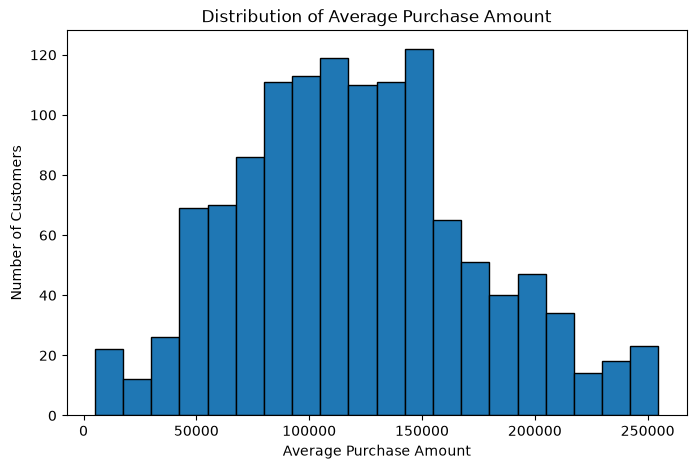

In [5]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_to_save["AveragePurchaseAmount"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Average Purchase Amount")
plt.xlabel("Average Purchase Amount")
plt.ylabel("Number of Customers")

plt.show()

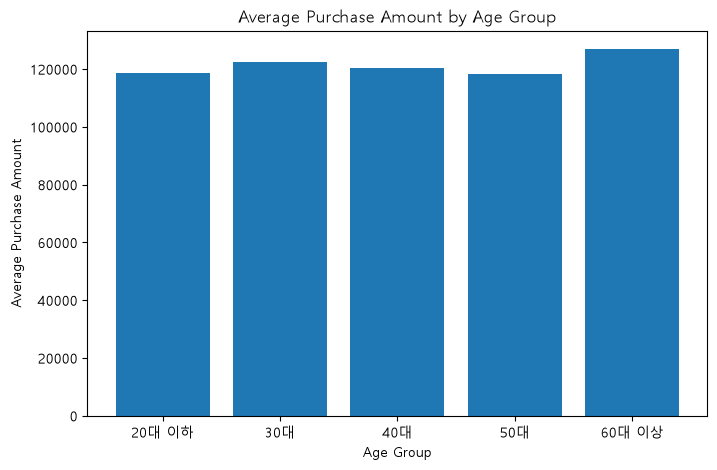

In [6]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

import matplotlib.pyplot as plt

age_purchase = df_to_save.groupby("AgeGroup")["AveragePurchaseAmount"].mean()

plt.figure(figsize=(8, 5))

plt.bar(age_purchase.index.astype(str), age_purchase.values)

plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")

plt.show()

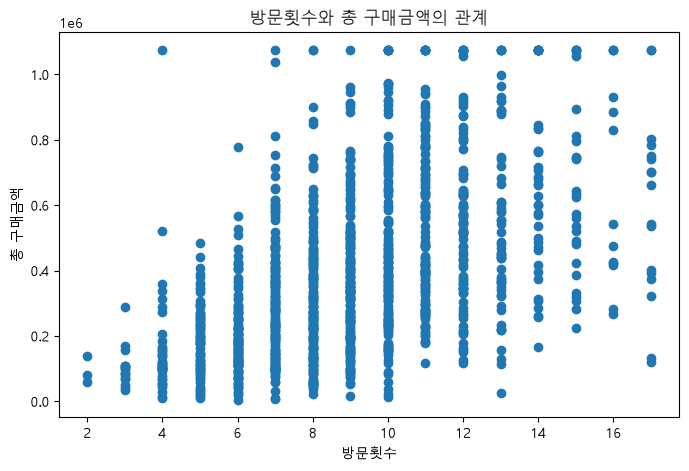

In [7]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.

plt.figure(figsize=(8, 5))

plt.scatter(
    df_to_save["VisitCount"],
    df_to_save["TotalPurchaseAmount"]
)

plt.title("방문횟수와 총 구매금액의 관계")
plt.xlabel("방문횟수")
plt.ylabel("총 구매금액")

plt.show()

### 문제 2 결과 정리

- 주요 변수의 분포 특징: 낮은 금액부터 높은 금액까지 비교적 넓은 범위에 분포하는 것으로 확인됐다.
- 고객 집단별 차이: 20대 이하가 가장 낮고 60대 이상이 가장 높지만 전체적으로 약 10~12만원 사이다.
- 두 변수 사이에서 확인한 관계: 방문횟수와 총 구매금액의 산점도를 확인한 결과 방문횟수가 증가할수록 총 구매금액도 증가하는 경향이 나타났다.
- 시각화 결과가 고객 분석에 주는 의미: 방문 빈도가 높은 고객이나 구매금액이 높은 고객군을 파악하고, 향후 마케팅 전략을 수립하는데 활용할 수 있다.


# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

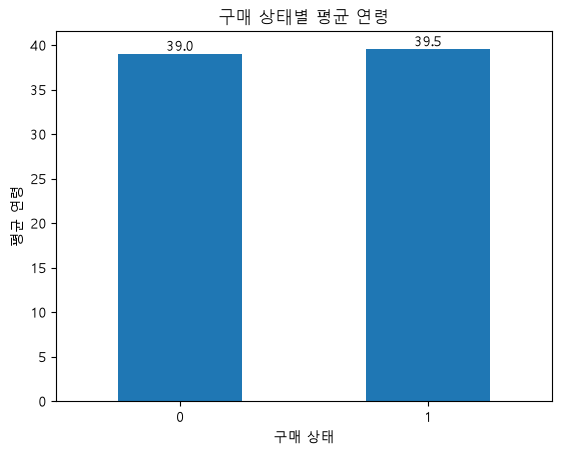

In [12]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

age_mean = df_to_save.groupby("PurchaseStatus")["Age"].mean()

ax = age_mean.plot(kind="bar")

plt.title("구매 상태별 평균 연령")
plt.xlabel("구매 상태")
plt.ylabel("평균 연령")
plt.xticks(rotation=0)

for i, value in enumerate(age_mean):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.show()


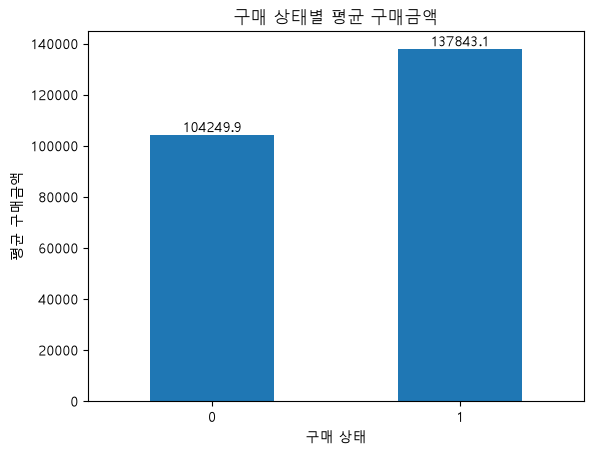

In [14]:
average_purchase_mean = df_to_save.groupby("PurchaseStatus")["AveragePurchaseAmount"].mean()

ax = average_purchase_mean.plot(kind="bar")

plt.title("구매 상태별 평균 구매금액")
plt.xlabel("구매 상태")
plt.ylabel("평균 구매금액")
plt.xticks(rotation=0)

for i, value in enumerate(average_purchase_mean):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.show()

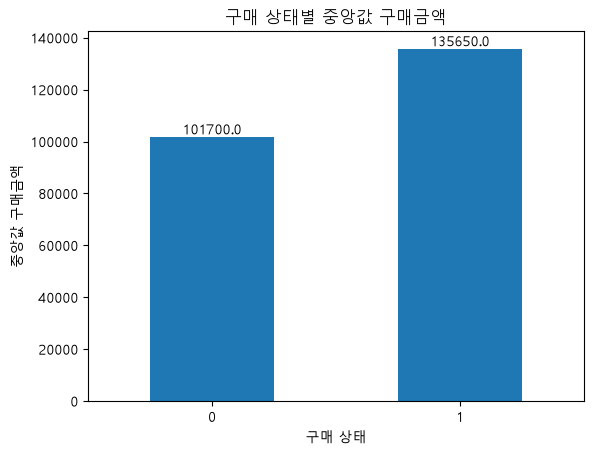

In [15]:
average_purchase_median = df_to_save.groupby("PurchaseStatus")["AveragePurchaseAmount"].median()

ax = average_purchase_median.plot(kind="bar")

plt.title("구매 상태별 중앙값 구매금액")
plt.xlabel("구매 상태")
plt.ylabel("중앙값 구매금액")
plt.xticks(rotation=0)

for i, value in enumerate(average_purchase_median):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.show()

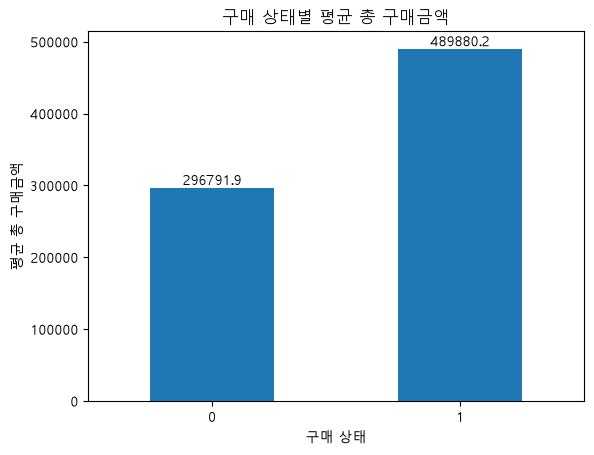

In [16]:
total_purchase_mean = df_to_save.groupby("PurchaseStatus")["TotalPurchaseAmount"].mean()

ax = total_purchase_mean.plot(kind="bar")

plt.title("구매 상태별 평균 총 구매금액")
plt.xlabel("구매 상태")
plt.ylabel("평균 총 구매금액")
plt.xticks(rotation=0)

for i, value in enumerate(total_purchase_mean):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.show()

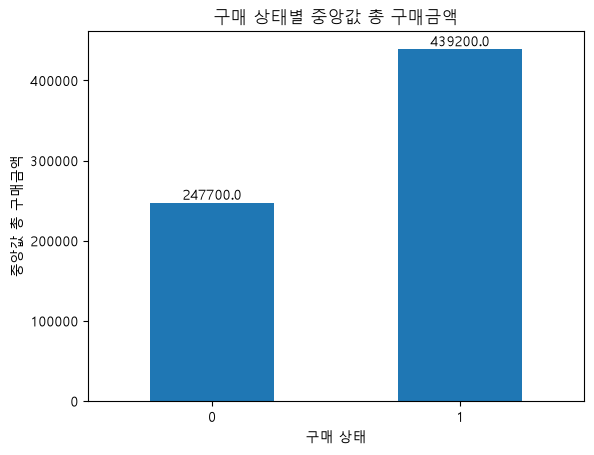

In [17]:
total_purchase_median = df_to_save.groupby("PurchaseStatus")["TotalPurchaseAmount"].median()

ax = total_purchase_median.plot(kind="bar")

plt.title("구매 상태별 중앙값 총 구매금액")
plt.xlabel("구매 상태")
plt.ylabel("중앙값 총 구매금액")
plt.xticks(rotation=0)

for i, value in enumerate(total_purchase_median):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.show()

In [18]:
gender_status = pd.crosstab(
    df_to_save["Gender"],
    df_to_save["PurchaseStatus"],
    normalize="index"
) * 100

print(gender_status)

PurchaseStatus          0          1
Gender                              
Female          50.760608  49.239392
Male            64.285714  35.714286


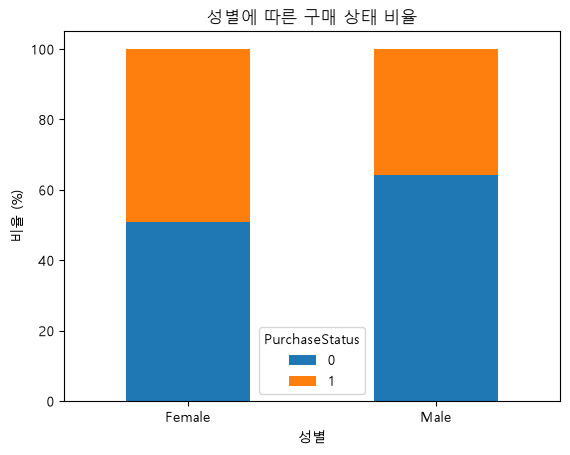

In [19]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

gender_status.plot(kind="bar", stacked=True)

plt.title("성별에 따른 구매 상태 비율")
plt.xlabel("성별")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="PurchaseStatus")

plt.show()

In [20]:
region_status = pd.crosstab(
    df_to_save["Region"],
    df_to_save["PurchaseStatus"],
    normalize="index"
) * 100

print(region_status)

PurchaseStatus          0          1
Region                              
Busan           55.454545  44.545455
Daegu           41.052632  58.947368
Daejeon         48.571429  51.428571
Gwangju         58.461538  41.538462
Gyeonggi        52.681388  47.318612
Incheon         49.557522  50.442478
Seoul           49.162011  50.837989


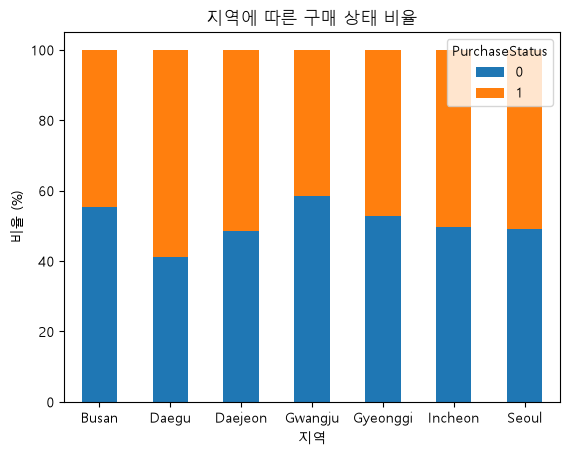

In [21]:
region_status.plot(kind="bar", stacked=True)

plt.title("지역에 따른 구매 상태 비율")
plt.xlabel("지역")
plt.ylabel("비율 (%)")
plt.xticks(rotation=0)
plt.legend(title="PurchaseStatus")

plt.show()

In [ ]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.

# Feature 후보: 구매 상태별 평균 총 구매금액, 구매 상태별 중앙값 총 구매금액
# 제외 후보: 구매 상태별 평균 연령

### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature: 구매 상태별 평균 총 구매금액, 구매 상태별 중앙값 총 구매금액
- 범주형 Feature: 성별에 따른 구매 상태 비율, 지역에 따른 구매 상태 비율
- 선정 근거: 구성 비율에 차이가 나타나는 가

#### 제외 후보

- 제외할 컬럼:구매 상태별 평균 연령
- 제외 이유: 뚜렷한 차이가 없음



# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
